In [1]:
# ============================================
# BLOCK 1: LOAD BEST MODEL AND EVALUATE
# ============================================
# WHAT THIS DOES:
# - Loads the best model (XGBoost)
# - Makes predictions on test data
# - Shows detailed metrics
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

print("="*60)
print("MODEL EVALUATION AND INTERPRETATION")
print("="*60)

# Load the best model
processed_path = '../data/processed/'
best_model = joblib.load(f'{processed_path}best_model.pkl')

# Load test data
df = pd.read_csv(f'{processed_path}processed_data_clean.csv')

# Prepare features and target
feature_cols = [col for col in df.columns if col != 'CVD_Risk_Encoded']
X = df[feature_cols]
y = df['CVD_Risk_Encoded']

# Train-test split (same as before)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# For XGBoost, remap target
class_mapping = {1: 0, 2: 1}
y_test_mapped = y_test.map(class_mapping)

# Predictions
y_pred_mapped = best_model.predict(X_test)
y_pred = np.array([1 if pred == 0 else 2 for pred in y_pred_mapped])
y_pred_proba = best_model.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nBest Model (XGBoost) Performance on Test Set:")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['INTERMEDIARY', 'HIGH']))

MODEL EVALUATION AND INTERPRETATION

Best Model (XGBoost) Performance on Test Set:
   Accuracy:  0.9084
   Precision: 0.9169
   Recall:    0.9084
   F1-Score:  0.9070

Classification Report:
              precision    recall  f1-score   support

INTERMEDIARY       0.98      0.81      0.89       116
        HIGH       0.87      0.99      0.92       146

    accuracy                           0.91       262
   macro avg       0.92      0.90      0.90       262
weighted avg       0.92      0.91      0.91       262




CONFUSION MATRIX


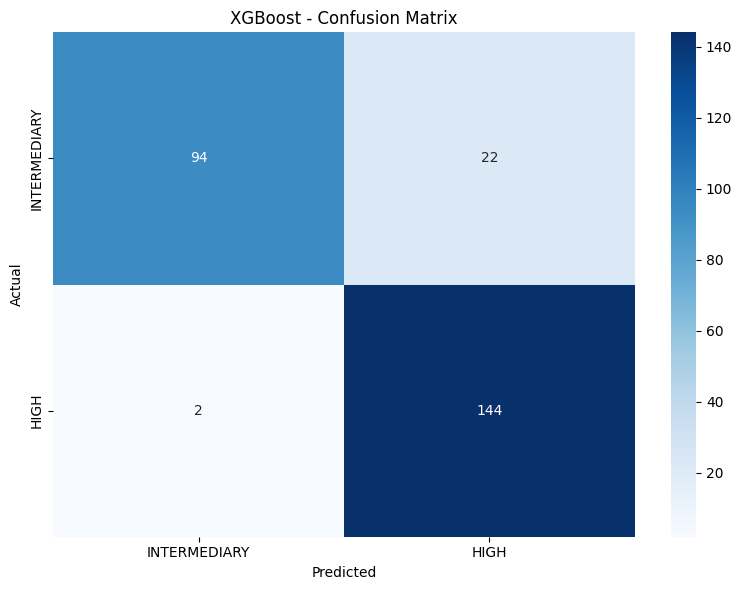


Confusion Matrix Details:
   True Negatives:  94
   False Positives: 22
   False Negatives: 2
   True Positives:  144


In [2]:
# ============================================
# BLOCK 2: CONFUSION MATRIX
# ============================================

print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['INTERMEDIARY', 'HIGH'],
            yticklabels=['INTERMEDIARY', 'HIGH'])
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../images/best_model_confusion_matrix.png')
plt.show()

# Calculate and display per-class metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Details:")
print(f"   True Negatives:  {tn}")
print(f"   False Positives: {fp}")
print(f"   False Negatives: {fn}")
print(f"   True Positives:  {tp}")


ROC CURVE AND AUC


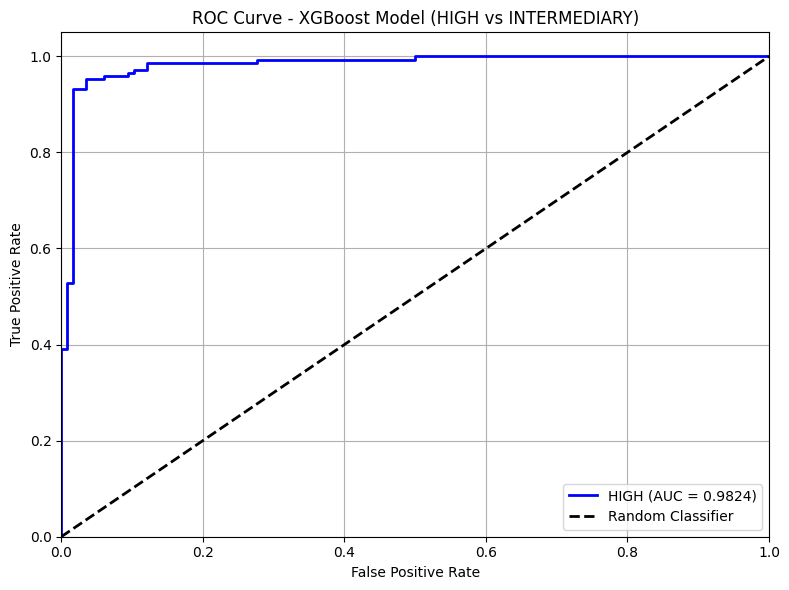


AUC Score (HIGH vs INTERMEDIARY): 0.9824

Interpretation:
   Excellent discrimination (AUC >= 0.90)


In [4]:
# ============================================
# BLOCK 3: ROC CURVE AND AUC (FIXED)
# ============================================

print("\n" + "="*60)
print("ROC CURVE AND AUC")
print("="*60)

# For binary classification, we only need one ROC curve
# Since we have 2 classes (INTERMEDIARY=1, HIGH=2), we treat HIGH as positive class

# Get probabilities for the positive class (HIGH = class 2)
# y_pred_proba shape: (n_samples, 2) -> columns: [INTERMEDIARY, HIGH]
# We need probabilities for class 2 (HIGH)
y_proba_high = y_pred_proba[:, 1]  # Probability of HIGH class

# Convert y_test to binary: 1 if HIGH, 0 if INTERMEDIARY
y_test_binary = (y_test == 2).astype(int)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_binary, y_proba_high)
roc_auc = roc_auc_score(y_test_binary, y_proba_high)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'HIGH (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Model (HIGH vs INTERMEDIARY)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig('../images/best_model_roc_curves.png')
plt.show()

print(f"\nAUC Score (HIGH vs INTERMEDIARY): {roc_auc:.4f}")
print(f"\nInterpretation:")
if roc_auc >= 0.90:
    print("   Excellent discrimination (AUC >= 0.90)")
elif roc_auc >= 0.80:
    print("   Good discrimination (AUC >= 0.80)")
elif roc_auc >= 0.70:
    print("   Fair discrimination (AUC >= 0.70)")
else:
    print("   Poor discrimination (AUC < 0.70)")


FINAL FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
                      Feature  Importance
                  Age_Elderly    0.091791
      Diabetes Status_Encoded    0.071240
Family History of CVD_Encoded    0.062792
       Smoking Status_Encoded    0.055733
               Smoking Status    0.053129
        Family History of CVD    0.040618
               CVD Risk Score    0.039498
              Metabolic_Score    0.034518
                 Obesity_Risk    0.032058
      Physical_Activity_Score    0.031598
              BMI_Underweight    0.028986
              Diabetes Status    0.028094
                   Age_Middle    0.026550
                    Age_Adult    0.025263
                          Age    0.024239


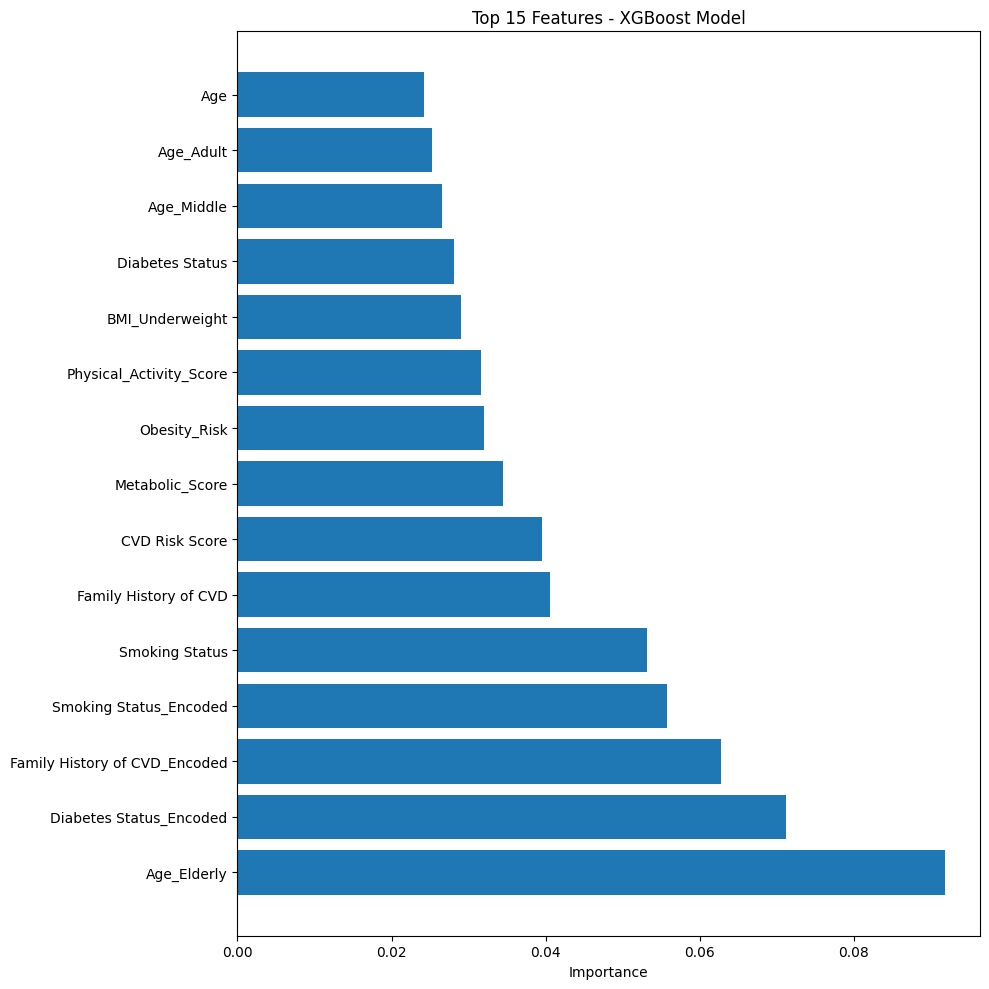


Feature importance saved to: ../data/processed/feature_importance.csv


In [5]:
# ============================================
# BLOCK 4: FEATURE IMPORTANCE (FINAL)
# ============================================

print("\n" + "="*60)
print("FINAL FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance from XGBoost
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 10))
top_features = importance_df.head(15)
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 15 Features - XGBoost Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../images/final_feature_importance.png')
plt.show()

# Save to CSV
importance_df.to_csv('../data/processed/feature_importance.csv', index=False)
print("\nFeature importance saved to: ../data/processed/feature_importance.csv")

In [11]:
# ============================================
# BLOCK 5: PREDICT ON NEW SAMPLE DATA (FIXED)
# ============================================

print("\n" + "="*60)
print("PREDICT ON NEW SAMPLE DATA")
print("="*60)

# Create a sample patient with realistic values
# Note: The features should match what was used in training
# We'll create a dictionary with key features

sample_patient = {
    'Age': 55,
    'BMI': 32.5,
    'Systolic BP': 145,
    'Diastolic BP': 90,
    'Total Cholesterol (mg/dL)': 240,
    'HDL (mg/dL)': 40,
    'Fasting Blood Sugar (mg/dL)': 130,
}

# Add encoded categorical features (these would come from the encoding step)
sample_patient['Sex_Encoded'] = 1  # 1 = Male, 0 = Female
sample_patient['Smoking Status_Encoded'] = 1  # 1 = Yes, 0 = No
sample_patient['Diabetes Status_Encoded'] = 1  # 1 = Yes, 0 = No
sample_patient['Family History of CVD_Encoded'] = 0  # 1 = Yes, 0 = No
sample_patient['Physical_Activity_Encoded'] = 1  # 0=Low, 1=Moderate, 2=High
sample_patient['Blood_Pressure_Encoded'] = 2  # 0=Normal, 1=Elevated, 2=Stage1, 3=Stage2

# Create DataFrame from sample
sample_df = pd.DataFrame([sample_patient])

# Ensure all required features are present
for col in feature_cols:
    if col not in sample_df.columns:
        sample_df[col] = 0

# Reorder columns to match training data
sample_df = sample_df[feature_cols]

# Make prediction
pred_mapped = best_model.predict(sample_df)[0]
pred_original = 1 if pred_mapped == 0 else 2
pred_proba = best_model.predict_proba(sample_df)[0]

risk_map = {1: 'INTERMEDIARY', 2: 'HIGH'}
print(f"\nPrediction for Sample Patient:")
print(f"   Age: {sample_patient['Age']}")
print(f"   BMI: {sample_patient['BMI']}")
print(f"   Systolic BP: {sample_patient['Systolic BP']}")
print(f"   Total Cholesterol: {sample_patient['Total Cholesterol (mg/dL)']}")
print(f"\n   Predicted Class: {pred_original} ({risk_map[pred_original]})")
print(f"   Probability Scores:")
print(f"      INTERMEDIARY: {pred_proba[0]:.4f} ({pred_proba[0]*100:.2f}%)")
print(f"      HIGH: {pred_proba[1]:.4f} ({pred_proba[1]*100:.2f}%)")


PREDICT ON NEW SAMPLE DATA

Prediction for Sample Patient:
   Age: 55
   BMI: 32.5
   Systolic BP: 145
   Total Cholesterol: 240

   Predicted Class: 1 (INTERMEDIARY)
   Probability Scores:
      INTERMEDIARY: 0.5666 (56.66%)
      HIGH: 0.4334 (43.34%)


In [12]:
# ============================================
# BLOCK 6: SAVE EVALUATION RESULTS (FIXED)
# ============================================

print("\n" + "="*60)
print("SAVING EVALUATION RESULTS")
print("="*60)

# Create results summary
# Note: cv_scores is not available in this notebook
# We'll use only the test metrics

results = {
    'Model': 'XGBoost',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'AUC_HIGH_vs_INTERMEDIARY': roc_auc
}

results_df = pd.DataFrame([results])
results_df.to_csv('../data/processed/model_results.csv', index=False)
print("Results saved to: ../data/processed/model_results.csv")

# Also save the classification report
report = classification_report(y_test, y_pred, target_names=['INTERMEDIARY', 'HIGH'], output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv('../data/processed/classification_report.csv')
print("Classification report saved to: ../data/processed/classification_report.csv")

print("\n" + "="*60)
print("MODEL EVALUATION COMPLETE")
print("="*60)

print("\nModel Performance Summary:")
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"   F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"   AUC:       {roc_auc:.4f} ({roc_auc*100:.2f}%)")

print("\nFiles saved in data/processed/:")
print("   - best_model.pkl")
print("   - xgboost_model.pkl")
print("   - random_forest_model.pkl")
print("   - scaler.pkl")
print("   - feature_importance.csv")
print("   - model_results.csv")
print("   - classification_report.csv")


SAVING EVALUATION RESULTS
Results saved to: ../data/processed/model_results.csv
Classification report saved to: ../data/processed/classification_report.csv

MODEL EVALUATION COMPLETE

Model Performance Summary:
   Accuracy:  0.9084 (90.84%)
   Precision: 0.9169 (91.69%)
   Recall:    0.9084 (90.84%)
   F1-Score:  0.9070 (90.70%)
   AUC:       0.9824 (98.24%)

Files saved in data/processed/:
   - best_model.pkl
   - xgboost_model.pkl
   - random_forest_model.pkl
   - scaler.pkl
   - feature_importance.csv
   - model_results.csv
   - classification_report.csv
